# Langgraph – wprowadzenie i LLMy – zadania

**Uwaga** – w celu lepszego przyswojenia wiedzy nie kopiuj kodu z notebooków z przykładami, tylko pisz go w całości samodzielnie

Dane do ćwiczeń: plik `recenzje.json` w katalogu głównym – 10 recenzji filmowych (pozytywne, neutralne, negatywne).

Zbudujesz pipeline analizujący recenzję filmową: rozbija tekst na słowa, oblicza statystyki, ocenia sentyment przez LLM i formatuje końcowy raport.

## Stan (TypedDict)

1. Zdefiniuj `State` dla pipeline'u. Stan powinien zawierać pola:
- `raw_text: str` – surowy tekst recenzji
- `words: list[str]` – lista słów
- `word_count: int` – łączna liczba słów
- `unique_count: int` – liczba unikalnych słów
- `sentiment: str` – ocena sentymentu zwrócona przez LLM
- `report: str` – końcowy raport z analizy

---
(czas: 5 min.)

In [1]:
from typing import TypedDict


class State(TypedDict):
    raw_text: str
    words: list[str]
    word_count: int
    unique_count: int
    sentiment: str
    report: str

## Node'y

2. Napisz node `extract_words_node(state: State)`, który rozbija `raw_text` na listę słów i zapisuje wynik do `words`.

---
(czas: 3 min.)

In [2]:
def extract_words_node(state: State):
    return {"words": state["raw_text"].lower().split()}

3. Napisz node `count_statistics_node(state: State)`, który na podstawie listy `words` oblicza `word_count` (łączna liczba słów) oraz `unique_count` (liczba unikalnych słów).

---
(czas: 3 min.)

In [3]:
def count_statistics_node(state: State):
    words = state["words"]
    return {"word_count": len(words), "unique_count": len(set(words))}

4. Napisz node `analyze_sentiment_node(state: State, config: RunnableConfig)`, który:
- odczytuje `model_name` (domyślnie `"openai/gpt-4o-mini"`) i `temperature` (domyślnie `0.0`) z `configurable`
- buduje prompt z wiadomością `system` i wiadomością `user` zawierającą `raw_text` recenzji
- wywołuje `ChatOpenAI` i zapisuje odpowiedź do pola `sentiment`

Sentyment powinien być pozytywny, neutralny lub negatywny.

---
(czas: 8 min.)

In [4]:
from dotenv import load_dotenv
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI

load_dotenv()


def analyze_sentiment_node(state: State, config: RunnableConfig):
    configurable = config.get("configurable", {})
    model_name = configurable.get("model_name", "openai/gpt-4o-mini")
    temperature = configurable.get("temperature", 0.0)

    llm = ChatOpenAI(model=model_name, temperature=temperature)
    messages = [
        {"role": "system", "content": "Evaluate the sentiment of the movie review. Reply with a single word: pozytywna, neutralna or negatywna."},
        {"role": "user", "content": state["raw_text"]},
    ]
    response = llm.invoke(messages)
    return {"sentiment": response.content.strip().lower()}

5. Napisz node `build_report_node(state: State)`, który zbiera dane ze stanu i formatuje czytelny tekst raportu zapisywany do `report`. Raport powinien zawierać co najmniej: fragment recenzji, liczbę słów, liczbę unikalnych słów i ocenę sentymentu.

---
(czas: 5 min.)

In [5]:
def build_report_node(state: State):
    report = (
        f"Review: {state['raw_text'][:80]}...\n"
        f"Word count: {state['word_count']}\n"
        f"Unique words: {state['unique_count']}\n"
        f"Sentiment: {state['sentiment']}"
    )
    return {"report": report}

## Graf

6. Zbuduj `StateGraph(State)`. Dodaj wszystkie cztery node'y i połącz je krawędziami.

Skompiluj pipeline i wyświetl jego wizualizację.

---
(czas: 8 min.)

/home/patryk/miniconda3/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


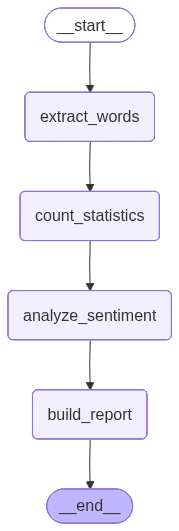

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


graph = StateGraph(State)

graph.add_node("extract_words", extract_words_node)
graph.add_node("count_statistics", count_statistics_node)
graph.add_node("analyze_sentiment", analyze_sentiment_node)
graph.add_node("build_report", build_report_node)

graph.add_edge(START, "extract_words")
graph.add_edge("extract_words", "count_statistics")
graph.add_edge("count_statistics", "analyze_sentiment")
graph.add_edge("analyze_sentiment", "build_report")
graph.add_edge("build_report", END)

pipeline = graph.compile()

display(Image(pipeline.get_graph().draw_mermaid_png(), width=120))

## Uruchomienie

7. Uruchom pipeline za pomocą `invoke` na wybranej recenzji z pliku `recenzje.json`. Zdefiniuj `runtime_config` z `model_name` i `temperature`. Wypisz `report` z wyniku.

---
(czas: 8 min.)

In [8]:
import json

with open("../Zadania/recenzje.json", encoding="utf-8") as f:
    reviews = json.load(f)

runtime_config = {
    "configurable": {
        "model_name": "openai/gpt-4o-mini",
        "temperature": 0.0,
    }
}

result = pipeline.invoke({"raw_text": reviews[0]["recenzja"]}, config=runtime_config)
print(result["report"])

Review: Absolutne arcydzieło. Nolan po raz kolejny udowodnił, że potrafi tworzyć kino na...
Word count: 30
Unique words: 30
Sentiment: pozytywna


8. Wczytaj plik `recenzje.json` i uruchom pipeline na wszystkich 10 recenzjach w pętli. Wypisz dla każdej z nich tytuł, oczekiwany sentyment z pliku JSON i sentyment zwrócony przez LLM. Sprawdź ile razy model się pomylił.

Jeśli zdążysz – zmień `system_prompt` i sprawdź czy model radzi sobie lepiej lub gorzej przy innym sformułowaniu instrukcji.

---
(czas: 10 min.)

In [ ]:
errors = 0

for rev in reviews:
    result = pipeline.invoke({"raw_text": rev["recenzja"]}, config=runtime_config)
    expected = rev["sentyment"]
    llm_result = result["sentiment"]
    match = "OK" if expected in llm_result else "ERROR"
    if match == "ERROR":
        errors += 1
    print(f"{rev['tytul']:<40} expected: {expected:<12} LLM: {llm_result:<12} {match}")

print(f"\nErrors: {errors}/10")